In [3]:
from lz78 import Sequence, CharacterMap, LZ78SPA, spa_from_file, get_top_counts_at_depths
import numpy as np
from os import makedirs
import time
import pandas as pd
import random
import argparse
import math
import itertools
from memory_profiler import profile
import os
from ushuffle import shuffle, Shuffler
from dataclasses import dataclass, field
import argparse
from sys import stdout
from glob import glob
import re

from tqdm import tqdm

import matplotlib.pyplot as plt

In [4]:
@dataclass
class DataSet:
    val_path: str
    train_path: str
    spa_paths: list[str]
    name:  str

In [5]:
# Change these if needed
GUE_DIR = "GUE"
BEST_SPAS_DIR = "results/best_spas"

In [6]:
DATA: list[DataSet] = []
for path in sorted(glob(f"{GUE_DIR}/*/*/dev.csv")):
    stem = re.sub(r'[/]', '_', path[len("GUE/"): -len("/dev.csv")])
    train_path = path[:-len("dev.csv")] + "train.csv"

    if "fungi" in stem or "virus_species_40" in stem:
        continue

    spas = sorted(glob(f"{BEST_SPAS_DIR}/{stem}_*.bin"))
    if len(spas) > 0:
        DATA.append(
            DataSet(
                train_path=train_path,
                val_path=path,
                spa_paths=spas,
                name=stem
            )
        )

In [7]:
def handle_N(data):
    new_data = []
    for _, row in data.iterrows():
        sequence, label = row['sequence'], row['label']
        processed_sequences =["".join(char for char in sequence if char in "ACGT")]
        
        for proc_seq in processed_sequences:
            new_data.append({"sequence": proc_seq, "label": label})
    return pd.DataFrame(new_data) 

In [8]:
@dataclass
class LogLossInfo:
    gap_when_correct: list[float] = field(default_factory=list)
    gap_when_incorrect: list[float] = field(default_factory=list)
    mean_log_loss_when_correct: list[float] = field(default_factory=list)
    std_log_loss_when_correct: list[float] = field(default_factory=list)
    mean_log_loss_of_correct_label_when_incorrect: list[float] = field(default_factory=list)
    std_log_loss_of_correct_label_when_incorrect: list[float] = field(default_factory=list)

    def add_entry(
        self,
        gap: float,
        mean_log_loss: float,
        std_log_loss: float,
        correct: bool,
    ):
        
        if correct:
            self.gap_when_correct.append(gap)
            self.mean_log_loss_when_correct.append(mean_log_loss)
            self.std_log_loss_when_correct.append(std_log_loss)
        else:
            self.gap_when_incorrect.append(gap)
            self.mean_log_loss_of_correct_label_when_incorrect.append(mean_log_loss)
            self.std_log_loss_of_correct_label_when_incorrect.append(std_log_loss)

def get_log_loss_gaps(
    data, spas, n_threads=32
):
    labels = data["label"]
    data = [Sequence(seq, charmap=CharacterMap("ACGT")) for seq in data["sequence"]]
    result = LogLossInfo()

    log_losses = np.zeros((len(spas), len(data)))
    std_log_losses = np.zeros((len(spas), len(data)))
    
    for i in range(len(spas)):
        results = spas[i].compute_test_loss_parallel(data, num_threads=n_threads, output_per_symbol_losses=True)
        log_losses[i, :] = [res["avg_log_loss"] for res in results]
        std_log_losses[i, :] = [np.std(res["log_losses"]) for res in results]


    for i in range(len(data)):
        losses = log_losses[:, i]
        true_label = labels[i]
        predicted_label = np.argmin(losses)
        correct = (predicted_label == true_label)
        sorted_losses = np.sort(losses)

        result.add_entry(
            gap=sorted_losses[1] - sorted_losses[0] if correct else abs(losses[true_label] - sorted_losses[0]),
            mean_log_loss=log_losses[true_label, i],
            std_log_loss=std_log_losses[true_label, i],
            correct=correct,
        )

    return result


In [9]:
output_data = []

for dataset in tqdm(DATA):
    validation_data = handle_N(pd.read_csv(dataset.val_path))
    stdout.flush()
    spas = [
        spa_from_file(path) for path in dataset.spa_paths
    ]

    log_loss_info = get_log_loss_gaps(
        validation_data, spas
    )

    output_data.append({
        "name": dataset.name,
        "mean_gap_when_correct": np.mean(log_loss_info.gap_when_correct),
        "mean_gap_when_incorrect": np.mean(log_loss_info.gap_when_incorrect),
        "median_gap_when_correct": np.median(log_loss_info.gap_when_correct),
        "median_gap": np.median(log_loss_info.gap_when_correct + log_loss_info.gap_when_incorrect),
        "median_gap_when_incorrect": np.median(log_loss_info.gap_when_incorrect),
        "std_gap_when_correct": np.std(log_loss_info.gap_when_correct),
        "std_gap_when_incorrect": np.std(log_loss_info.gap_when_incorrect),
        "mean_log_loss_when_correct": np.mean(log_loss_info.mean_log_loss_when_correct),
        "std_log_loss_when_correct": np.mean(log_loss_info.std_log_loss_when_correct),
        "mean_log_loss_of_correct_label_when_incorrect": np.mean(log_loss_info.mean_log_loss_of_correct_label_when_incorrect),
        "std_log_loss_of_correct_label_when_incorrect": np.mean(log_loss_info.std_log_loss_of_correct_label_when_incorrect),
    })

100%|██████████| 28/28 [01:23<00:00,  2.97s/it]


In [10]:
for out in tqdm(output_data):
    name = out["name"]
    dataset = next(ds for ds in DATA if ds.name == name)
    train_data = pd.read_csv(dataset.train_path)
    gc_content_per_label = {cls: [] for cls in range(len(dataset.spa_paths))}
    for _, row in train_data.iterrows():
        sequence, label = row['sequence'], row['label']
        gc_content = (sequence.count('G') + sequence.count('C')) / len(sequence) if len(sequence) > 0 else 0.0
        gc_content_per_label[label].append(gc_content)

    max_gc_content = max([np.mean(x) for x in gc_content_per_label.values()])
    min_gc_content = min([np.mean(x) for x in gc_content_per_label.values()])
    out["gc_content_diff"] = max_gc_content - min_gc_content
    out["mean_gc_content"] = np.mean(sum([list(x) for x in gc_content_per_label.values()], start=[]))
    

100%|██████████| 28/28 [00:24<00:00,  1.14it/s]


In [18]:
df = pd.DataFrame(output_data)
df["num_classes"] = 2
# covid has 9 classes and splice has 3
df.loc[df["name"] == "virus_covid", "num_classes"] = 9
df.loc[df["name"] == "splice_reconstructed", "num_classes"] = 3
df

,name,mean_gap_when_correct,mean_gap_when_incorrect,median_gap_when_correct,median_gap,median_gap_when_incorrect,std_gap_when_correct,std_gap_when_incorrect,mean_log_loss_when_correct,std_log_loss_when_correct,mean_log_loss_of_correct_label_when_incorrect,std_log_loss_of_correct_label_when_incorrect,gc_content_diff,mean_gc_content,num_classes
0,EMP_H3,0.035268,0.011729,0.030411,0.026848,0.008159,0.031156,0.016252,1.917732,0.370183,1.946619,0.346223,0.051917,0.384606,2
1,EMP_H3K14ac,0.074259,0.024949,0.069074,0.065505,0.016827,0.051333,0.024741,1.879304,0.438428,1.947628,0.456266,0.005445,0.381082,2
2,EMP_H3K36me3,0.095812,0.039293,0.090939,0.084614,0.027638,0.060115,0.041371,1.859098,0.443934,1.934178,0.470514,0.008347,0.381591,2
3,EMP_H3K4me1,0.083888,0.038224,0.078949,0.070618,0.026126,0.053722,0.037988,1.868141,0.444044,1.940671,0.464847,0.009873,0.381893,2
4,EMP_H3K4me2,0.073088,0.036500,0.068563,0.062282,0.023580,0.046837,0.039053,1.878227,0.425145,1.937328,0.448678,0.022950,0.381942,2
5,EMP_H3K4me3,0.169298,0.056955,0.165135,0.151917,0.039750,0.093662,0.055744,1.807984,0.548132,1.939613,0.578459,0.007528,0.381129,2
6,EMP_H3K79me3,0.035002,0.014464,0.032106,0.029764,0.009914,0.027842,0.017770,1.911729,0.359083,1.937296,0.369871,0.006578,0.379798,2
7,EMP_H3K9ac,0.164344,0.060516,0.154303,0.136709,0.033034,0.105820,0.068037,1.819457,0.556948,1.970802,0.581293,0.026685,0.381707,2
8,EMP_H4,0.027918,0.009782,0.024067,0.021888,0.007394,0.023932,0.008653,1.921646,0.358272,1.948932,0.344256,0.027472,0.378357,2
9,EMP_H4ac,0.093631,0.031885,0.089933,0.081788,0.021339,0.053933,0.032499,1.860453,0.442995,1.935925,0.470063,0.018247,0.380621,2


In [19]:
# df[prom tasks]
df[df["name"].str.contains("prom")]

,name,mean_gap_when_correct,mean_gap_when_incorrect,median_gap_when_correct,median_gap,median_gap_when_incorrect,std_gap_when_correct,std_gap_when_incorrect,mean_log_loss_when_correct,std_log_loss_when_correct,mean_log_loss_of_correct_label_when_incorrect,std_log_loss_of_correct_label_when_incorrect,gc_content_diff,mean_gc_content,num_classes
15,prom_prom_300_all,0.039531,0.017272,0.037049,0.033586,0.013763,0.023785,0.015111,1.927137,0.389819,1.976667,0.431621,0.068391,0.578255,2
16,prom_prom_300_notata,0.042147,0.014615,0.039659,0.036450,0.011990,0.025124,0.011960,1.927742,0.381126,1.987058,0.452859,0.070540,0.583564,2
17,prom_prom_300_tata,0.034073,0.022012,0.025049,0.021242,0.015014,0.036382,0.023736,1.903389,0.415632,1.938482,0.401237,0.048841,0.530580,2
18,prom_prom_core_all,0.058665,0.033996,0.054318,0.047014,0.026920,0.037480,0.027530,1.926164,0.381480,1.985770,0.426564,0.087271,0.585382,2
19,prom_prom_core_notata,0.063828,0.033840,0.059571,0.051526,0.026830,0.039513,0.028595,1.922293,0.393524,1.988425,0.449308,0.086054,0.594968,2
20,prom_prom_core_tata,0.066154,0.035883,0.056710,0.051225,0.026421,0.045731,0.029791,1.899506,0.405438,1.960259,0.388691,0.091493,0.501873,2


In [20]:
datasets = [
    "EMP_H3", "EMP_H3K14ac", "EMP_H3K36me3", "EMP_H3K4me1", "EMP_H3K4me2", "EMP_H3K4me3",
    "EMP_H3K79me3", "EMP_H3K9ac", "EMP_H4", "EMP_H4ac", "virus_covid", "mouse_0", "mouse_1",
    "mouse_2", "mouse_3", "mouse_4", "prom_prom_300_all","prom_prom_300_notata", "prom_prom_300_tata",
    "prom_prom_core_all", "prom_prom_core_notata", "prom_prom_core_tata", "splice_reconstructed",
    "tf_0", "tf_1", "tf_2", "tf_3", "tf_4"
]

dna_bert = list(map(float,
"""78.27 52.57 56.88 50.52 31.13 36.27 67.39 55.63 80.71 50.43
71.02 56.26 84.77 79.32 66.47 52.66 71.59 94.27 86.77 74.17
68.04 69.37 84.99 71.99 76.06 66.52 58.54 77.43""".split()))

lz78 = list(map(float,
"""76 84.7 78.39 66.19 67.8 77.96 77.33 73.31 77.33 79.69
72.39 50.71 70.44 73.16 56.82 38.21 68.11 76.52 25.97 53.91
57.58 50.14 38.63 60.38 65.1 58.06 42.98 72.19""".split()))

cnn = list(map(float,
"""61.52 29.73 38.6 26.06 25.76 20.52 46.3 40.03 62.34 25.54
22.23 31.14 59.74 63.15 45.48 27.18 75.78 85.14 70.3 58.07
60.09 69.33 76.79 53.95 63.2 45.22 29.84 61.48""".split()))

In [21]:
improvement = {
    datasets[i]: (lz78[i] - dna_bert[i]) / dna_bert[i] for i in range(len(datasets))
}
df["improvement"] = [improvement[name] for name in df["name"]]

improvement_cnn = {
    datasets[i]: (lz78[i] - cnn[i]) / cnn[i] for i in range(len(datasets))
}
df["improvement_cnn"] = [improvement_cnn[name] for name in df["name"]]

In [22]:
df["lz78_metric"] = [lz78[datasets.index(name)] for name in df["name"]]

In [33]:
# df["predictor"] = df["std_gap_when_correct"] / df["mean_gap_when_correct"]
# df["predictor"] = np.minimum(
#     df["std_log_loss_of_correct_label_when_incorrect"] / df["mean_log_loss_of_correct_label_when_incorrect"],
#     0.3
# )
df["predictor"] = df["median_gap"]

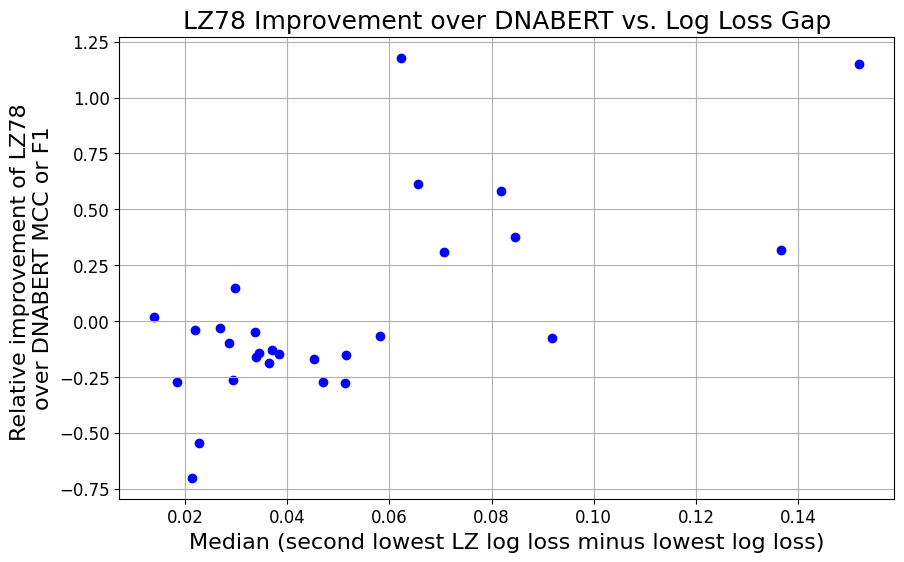

In [42]:
# plot improvement vs. various things
plt.figure(figsize=(10, 6))
plt.grid(True)

plt.scatter(
    df["predictor"],
    df["improvement"],
    color='blue'
)
plt.ylabel("Relative improvement of LZ78 \nover DNABERT MCC or F1", fontsize=16)
plt.xlabel("Median (second lowest LZ log loss minus lowest log loss)", fontsize=16)
# make fonts bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("LZ78 Improvement over DNABERT vs. Log Loss Gap", fontsize=18)
plt.show()

In [43]:
# predictor_variable = np.minimum(df["predictor"], 1)
predictor_variable = df["predictor"]

In [44]:
# find correlation coeff
correlation = np.corrcoef(predictor_variable, df["improvement"])[0, 1]
print(f"Correlation coefficient: {correlation}")

Correlation coefficient: 0.6738753799679239


In [45]:
# spearman correlation
from scipy.stats import spearmanr
spearman_corr, _ = spearmanr(predictor_variable, df["improvement"])
print(f"Spearman correlation: {spearman_corr}")

Spearman correlation: 0.5123152709359605


In [29]:
df["predictor"] = df["gc_content_diff"] / df["mean_gc_content"]

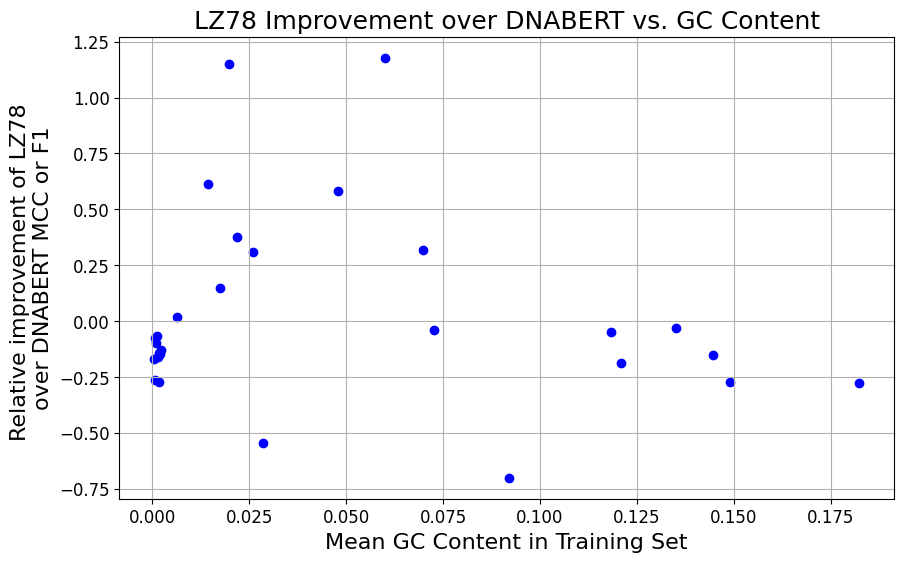

In [30]:
# plot improvement vs. various things
plt.figure(figsize=(10, 6))
plt.grid(True)

plt.scatter(
    df["predictor"],
    df["improvement"],
    color='blue'
)
plt.ylabel("Relative improvement of LZ78 \nover DNABERT MCC or F1", fontsize=16)
plt.xlabel("Mean GC Content in Training Set", fontsize=16)
# make fonts bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("LZ78 Improvement over DNABERT vs. GC Content", fontsize=18)
plt.show()

In [31]:
# predictor_variable = np.minimum(df["predictor"], 1)
predictor_variable = df["predictor"]
# find correlation coeff
correlation = np.corrcoef(predictor_variable, df["improvement"])[0, 1]
print(f"Correlation coefficient: {correlation}")

Correlation coefficient: -0.15589180811282008


In [7]:
@dataclass
class GCContentInfo:
    gc_content_when_correct: list[float] = field(default_factory=list)
    gc_content_when_incorrect: list[float] = field(default_factory=list)
    gc_content_per_classified_class: dict[int, list[float]] = field(default_factory=dict)
    gc_content: list[float] = field(default_factory=list)
    log_loss: dict[int, list[float]] = field(default_factory=dict)

    def add_entry(
        self,
        gc_content: float,
        log_losses: dict[int, float],
        correct: bool,
        classified_class: int
    ):
        
        if correct:
            self.gc_content_when_correct.append(gc_content)
        else:
            self.gc_content_when_incorrect.append(gc_content)
        if classified_class not in self.gc_content_per_classified_class:
            self.gc_content_per_classified_class[classified_class] = []
        self.gc_content_per_classified_class[classified_class].append(gc_content)
        self.gc_content.append(gc_content)

        for cls, log_loss in log_losses.items():
            if cls not in self.log_loss:
                self.log_loss[cls] = []
            self.log_loss[cls].append(log_loss)


def get_gc_content_info(
    data, spas, n_threads=32
):
    labels = data["label"]

    # gc content
    gc_contents = [ (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0.0 for seq in data["sequence"]]
    data = [Sequence(seq, charmap=CharacterMap("ACGT")) for seq in data["sequence"]]
    result = GCContentInfo()

    log_losses = np.zeros((len(spas), len(data)))
    
    for i in range(len(spas)):
        results = spas[i].compute_test_loss_parallel(data, num_threads=n_threads, output_per_symbol_losses=True)
        log_losses[i, :] = [res["avg_log_loss"] for res in results]


    for i in range(len(data)):
        losses = log_losses[:, i]
        true_label = labels[i]
        predicted_label = np.argmin(losses)
        correct = (predicted_label == true_label)

        result.add_entry(
            gc_content=gc_contents[i],
            correct=correct,
            classified_class=predicted_label,
            log_losses={cls: log_losses[cls, i] for cls in range(len(spas))}
        )

    return result


In [ ]:
output_data = {}

for dataset in tqdm(DATA):
    spas = [
        spa_from_file(path) for path in dataset.spa_paths
    ]
    # print percent of sequences that are each class
    print(f"Dataset name: {dataset.name}")
    train_data = pd.read_csv(dataset.train_path)
    # for cls in range(len(spas)):
        # print(f"Class {cls}: {np.sum(train_data['label'] == cls) / len(train_data['label']) * 100:.2f}%")
    validation_data = handle_N(pd.read_csv(dataset.val_path))
    stdout.flush()

    gc_content_info = get_gc_content_info(
        validation_data, spas
    )

    output_data[dataset.name] = gc_content_info

In [67]:
TASK = "prom_prom_core_all"
gc_info = output_data[TASK]

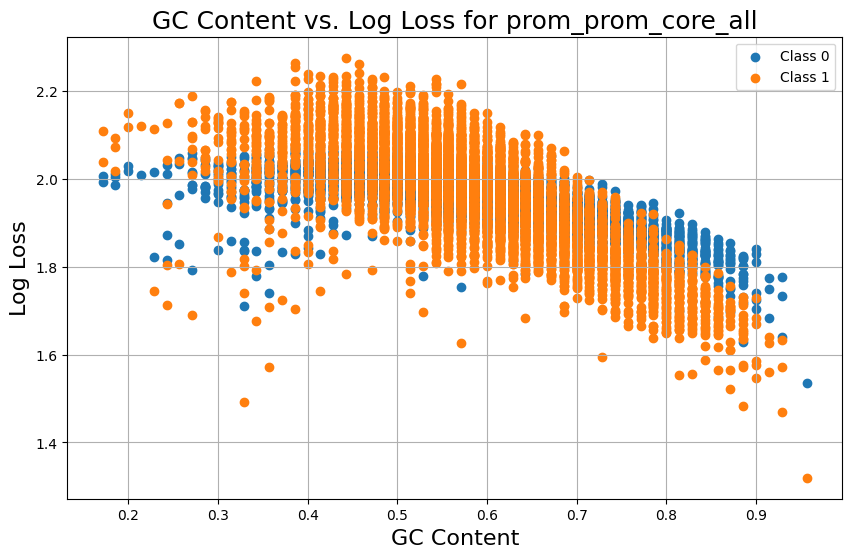

In [68]:
# plot gc content vs. log loss for each class
plt.figure(figsize=(10, 6))
plt.grid(True)
for cls in gc_info.log_loss.keys():
    plt.scatter(
        gc_info.gc_content,
        gc_info.log_loss[cls],
        label=f"Class {cls}"
    )
plt.xlabel("GC Content", fontsize=16)
plt.ylabel("Log Loss", fontsize=16)
plt.title(f"GC Content vs. Log Loss for {TASK}", fontsize=18)
plt.legend()
plt.show()

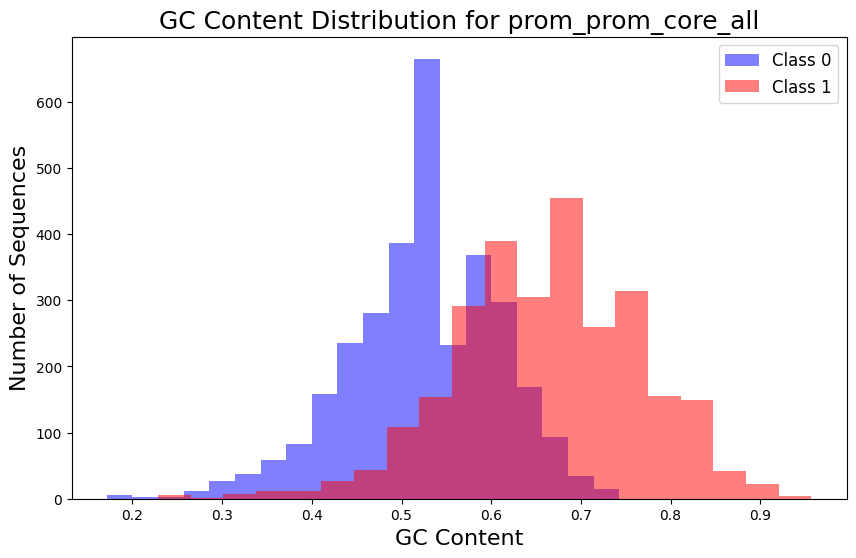

In [69]:
# do a historgram of gc_content when classified class 0 vs 1
color_map = {0: 'blue', 1: 'red', 2: 'green'}
plt.figure(figsize=(10, 6))
for cls in gc_info.gc_content_per_classified_class.keys():
    plt.hist(gc_info.gc_content_per_classified_class[cls], bins=20, alpha=0.5, label=f'Class {cls}', color=color_map[cls])
plt.xlabel("GC Content", fontsize=16)
plt.ylabel("Number of Sequences", fontsize=16)
plt.title(f"GC Content Distribution for {TASK}", fontsize=18)
plt.legend(fontsize=12)
plt.show()

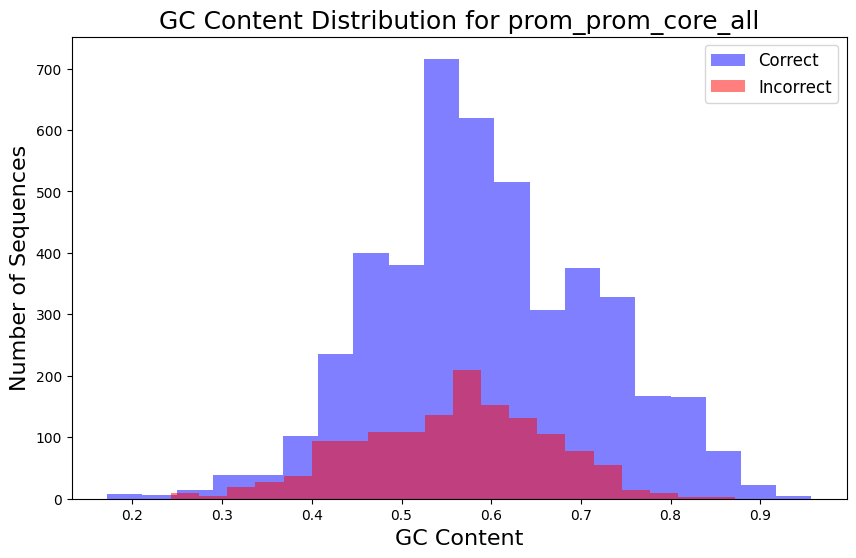

In [70]:
plt.figure(figsize=(10, 6))
plt.hist(gc_info.gc_content_when_correct, bins=20, alpha=0.5, label='Correct', color='blue')
plt.hist(gc_info.gc_content_when_incorrect, bins=20, alpha=0.5, label='Incorrect', color='red')
plt.xlabel("GC Content", fontsize=16)
plt.ylabel("Number of Sequences", fontsize=16)
plt.title(f"GC Content Distribution for {TASK}", fontsize=18)
plt.legend(fontsize=12)
plt.show()